# Setup
Build edges,nodes, and adjacency list from the input file. 

I also create a NetworkX graph for sanity checks and visualization.

In [16]:
import numpy as np
import networkx as nx

edges = np.loadtxt("data.txt", dtype=np.int64)
nodes = np.unique(edges)
adjacencies = {n: [] for n in nodes}                                     # list
# adjacencies_mat = np.zeros((len(nodes), len(nodes)), dtype=np.float64) # matrix (too expensive)
for src, dst in edges:
    adjacencies[src].append(dst)
    # adjacencies_mat[src, dst] = 1

graph = nx.DiGraph() # only used for sanity checks
for u, vs in adjacencies.items():
    graph.add_edges_from((u, v) for v in vs)


# Bincount: x[i] = how many times i appears in the input array
degrees_in = np.bincount(edges[:, 1], minlength=len(nodes))     # analogous to graph.in_degree()
degrees_out = np.bincount(edges[:, 0], minlength=len(nodes))    # analogous to graph.out_degree()

print(f"# of nodes: {len(nodes)}")
print(f"# of edges: {len(edges)}")
print(f"In-degree -> min: {degrees_in.min()}, max: {degrees_in.max()}, p75: {np.percentile(degrees_in[nodes], 75):.2f}, median: {np.median(degrees_in[nodes]):.2f}")
print(f"Out-degree -> min: {degrees_out.min()}, max: {degrees_out.max()}, p75: {np.percentile(degrees_out[nodes], 75):.2f}, median: {np.median(degrees_out[nodes]):.2f}")

# of nodes: 4039
# of edges: 88234
In-degree -> min: 0, max: 251, p75: 27.00, median: 11.00
Out-degree -> min: 0, max: 1043, p75: 26.00, median: 10.00


# Plotting the graph

## Degrees distribution
Since graph is directed, we have in- and out-degrees.

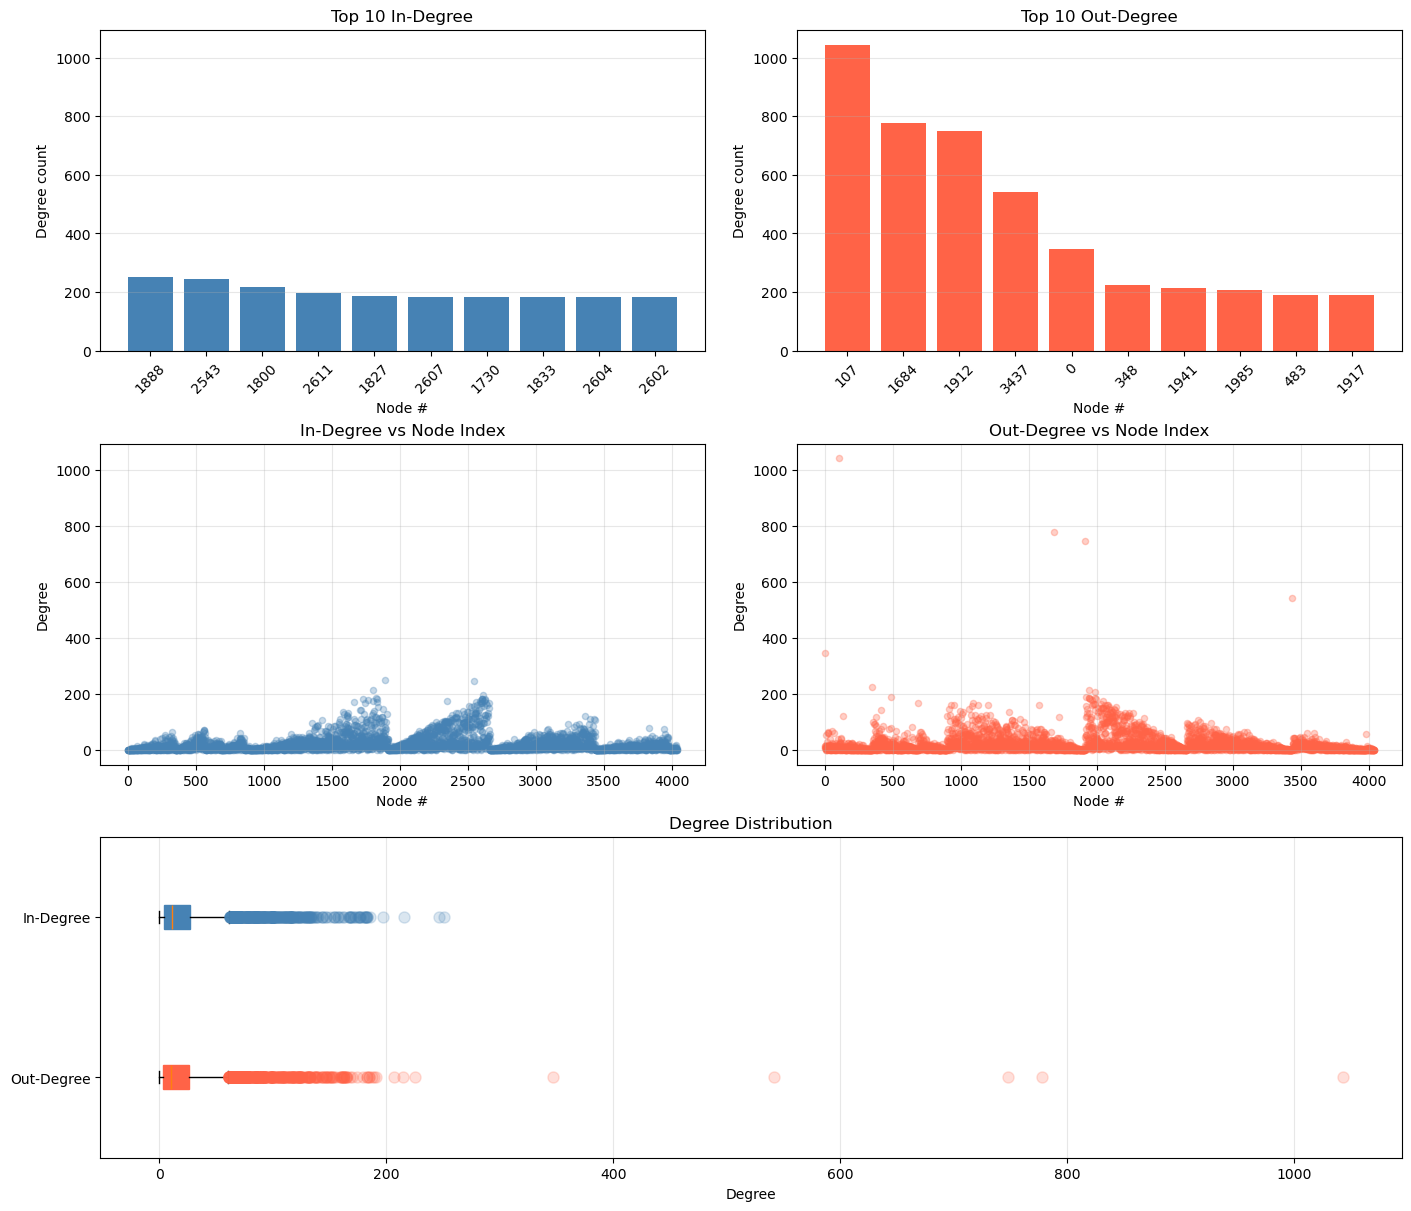

In [17]:
import matplotlib.pyplot as plt

top_out = np.argsort(degrees_out)[-10:][::-1]
top_in = np.argsort(degrees_in)[-10:][::-1]

fig = plt.figure(figsize=(14, 12), constrained_layout=True)
colors = ["steelblue", "tomato"] # in / out
gs = fig.add_gridspec(3, 2)

# Row 1 - bars
ax00 = fig.add_subplot(gs[0, 0])
ax01 = fig.add_subplot(gs[0, 1], sharey=ax00)

ax00.bar(range(10), degrees_in[top_in], color=colors[0])
ax00.set_title("Top 10 In-Degree")
ax00.set_xlabel("Node #")
ax00.set_ylabel("Degree count")
ax00.set_xticks(range(10))
ax00.set_xticklabels(top_in, rotation=45)
ax00.grid(True, alpha=0.3, axis="y")

ax01.bar(range(10), degrees_out[top_out], color=colors[1])
ax01.set_title("Top 10 Out-Degree")
ax01.set_xlabel("Node #")
ax01.set_ylabel("Degree count")
ax01.set_xticks(range(10))
ax01.set_xticklabels(top_out, rotation=45)
ax01.grid(True, alpha=0.3, axis="y")

# Row 2 - scatters
ax10 = fig.add_subplot(gs[1, 0])
ax11 = fig.add_subplot(gs[1, 1], sharey=ax10)

ax10.scatter(nodes, degrees_in[nodes], alpha=0.3, color=colors[0], s=20)
ax10.set_title("In-Degree vs Node Index")
ax10.set_xlabel("Node #")
ax10.set_ylabel("Degree")
ax10.grid(True, alpha=0.3)

ax11.scatter(nodes, degrees_out[nodes], alpha=0.3, color=colors[1], s=20)
ax11.set_title("Out-Degree vs Node Index")
ax11.set_xlabel("Node #")
ax11.set_ylabel("Degree")
ax11.grid(True, alpha=0.3)

# Row 3 - horizontal boxplot (spans both columns)
ax2 = fig.add_subplot(gs[2, :])
bp = ax2.boxplot(
    [degrees_out[nodes], degrees_in[nodes]],
    tick_labels=["Out-Degree", "In-Degree"],
    patch_artist=True,
    orientation="horizontal",
)

for box, c in zip(bp["boxes"], colors[::-1]):
    box.set_facecolor(c)
    box.set_edgecolor(c)

for flier, c in zip(bp["fliers"], colors[::-1]):
    flier.set_markersize(8)
    flier.set_alpha(0.2)
    flier.set_markerfacecolor(c)
    flier.set_markeredgecolor(c)

ax2.set_title("Degree Distribution")
ax2.set_xlabel("Degree")
ax2.grid(True, alpha=0.3, axis="x")

plt.show()

Nodes tend to "spread" more than they "gather" edges, like a hub-and-spoke structure.

# Centrality measures

## Betweenness centrality
> This is a **node-distance** based centrality measure, which means it's based on the shortest paths between nodes. It measures how many of such shortest paths pass through a given node.

For a node $v$ it is defined as:

$$
C(v)=\sum_{\substack{s \neq v \neq t}} \frac{\sigma_{s \to t}(v)}{\sigma_{s \to t}}
$$

where:

- $\sigma_{s \to t}$ = # of shortest paths $s \to t$
- $\sigma_{s \to t}(v)$ = # of those which _also_ pass through $v$

---

Here I'm using the **Brandes Algorithm**:

$$
C(v) = \sum_{s \neq v} \delta_s(v) \\
\delta_s(v) = \sum_{w: v \in P(w)} \frac{\sigma_{s \to v}}{\sigma_{s \to w}} (1 + \delta_s(w))
$$

In other words, $w$ is a children of node $v$ in all the shortest path tree rooted at $s$.

_For each_ source node $s$:
1. **Forward Step**: Do a *BFS* to find the shortest path(s) `s ->  all other nodes`. Results:
    1. S = [ `All nodes, sorted in order of distance from root node s` ]
    4. d = { n: `Minimum path distance from root node s to this node` }
    3. $\sigma$ = { n: `How many such shortest path(s) exist from root node s to this node` }
    2. P = { n: [`Predecessors in each of such shortest path(s) from root node s to this node`] }
2. **Backward Step**: Do a *backwards accumulation* of dependencies, starting from the furthest nodes to $s$. Results:
    1. $\delta$ = { n: `How many shortest paths from root node s to all other nodes pass through this node` }
    2. $C_B$ = { n: `Betweenness centrality of this node` }

In [18]:
def betweenness_centrality(adjacencies): # Brandes Algorithm
    betweenness = {n: 0.0 for n in adjacencies}

    # For each node as source
    for source in adjacencies:
        S = []                          # Sorted nodes in order of distance from source
        D = {n: -1 for n in adjacencies}      # For each node, the shortest distance from source
        sigma = {n: 0 for n in adjacencies}   # For each node, how many of such short paths from source
        P = {n: [] for n in adjacencies}      # For each node, the one predecessor in the shortest path(s) from source to it

        # Initialization for source
        sigma[source] = 1               # Only one shortest path to self
        D[source] = 0                   # Dist. to self is 0
        Q = [source]                    # Queue for BFS as starting point
        
        # 1. Forward step (BFS)
        while Q:                        # While there are nodes to explore 
            n = Q.pop(0)                # Dequeue (FIFO) next node to explore
            S.append(n)                 # Append to stack for later backtracking
            for w in adjacencies[n]:
                if D[w] < 0:            # For each NOT VISITED child 
                    Q.append(w)             # Enqueue for exploration and
                    D[w] = D[n] + 1         # Is one more step distant to source compared to current node
                if D[w] == D[n] + 1:    # For each (1) ALREADY VISITED child for which (2) the current node is on a shortest path to it
                    sigma[w] += sigma[n]    # Increase the number of shortest paths to it considering (!) the number of shortest paths to the current node
                    P[w].append(n)          # Add the current node as a predecessor on the shortest path to it

        # All the graph was traversed, now we have the shortest paths from source
        
        # 2. Backward step (dependencies aggregation - find out how much source depends on each node for its shortest paths)
        delta = {w: 0 for w in adjacencies}   # For each node, ratio of shortest paths from source to any node that pass through it ("dependency")
        while S:                        
            w = S.pop()                         # Start from the farthest node and go back to source
            coeff = (1 + delta[w]) / sigma[w]   # Ratio of shortest paths from source to any node that pass through the current node
            for n in P[w]:                      # For each predecessors in the shortest paths to the current node
                delta[n] += sigma[n] * coeff        # Dependency of the predecessor is increased by the dependency of the current node weighted by the ratio of shortest paths to it from source that pass through the current node
            if w != source:
                betweenness[w] += delta[w]      # Betweenness of the current node is increased by its dependency (except for source node)
                
    return betweenness

In [19]:
import networkx as nx

# According to betweeness criterion (how many shortest paths from any node to any other node pass through it)
c = betweenness_centrality(adjacencies) # centrality score of each node

# Sanity check with NetworkX implementation
c_nx = nx.betweenness_centrality(graph, normalized=False)
diff = np.array([abs(c[n] - c_nx[n]) for n in adjacencies])   # Difference between my implementation and NetworkX for each node
assert np.allclose(diff, 0.0, atol=1e-4), "Betweenness centrality values do not match NetworkX implementation!"

In [20]:
# List top 10 nodes with highest betweenness centrality score
top_betweenness = sorted(c.items(), key=lambda x: x[1], reverse=True)[:10]  # sort by dict value and pick the first 10
print("Top 10 nodes by betweenness centrality score:")
for node, score in top_betweenness:
    print(f"Node {node}: {score:.4f}")

Top 10 nodes by betweenness centrality score:
Node 1684: 537944.0089
Node 1912: 442512.6262
Node 1718: 433252.4800
Node 563: 212075.0273
Node 1405: 165030.0598
Node 1656: 153656.0281
Node 1086: 139435.1117
Node 567: 135307.7976
Node 3437: 133579.4364
Node 119: 103660.5979


## PageRank centrality
> This is a **spectral 👻** centrality measure, which means it's based on eigen-properties of the adjacency matrix. It measures how "important" a node is, based on the importance of its neighbors (scaled by the number of outgoing links). Since this recursive definition, we either use the power iteration method, or we can directly compute the eigenvector of the adjacency matrix.

For a node $v$ it is defined as:

$$ C(v) = \alpha \sum_{u} A_{u \to v}\frac{C(u)}{d_{out}(u)} + \beta $$

where:

- $\alpha$ = `damping factor` (usually set to 0.85)
- $\beta$ = `teleportation factor` (usually set to (1 - $\alpha$) / N, where N is the number of nodes)
- $A_{u \to v}$ = `adjacency of u->v` (1 if there is an edge from $u$ to $v$, 0 otherwise)

---

If we're interested in all nodes' centrality, we can use its analogous **vector form**:

$$
\begin{aligned}
\mathbf{C}
&= \alpha \mathbf{A}^\top \mathbf{D}_{out}^{-1}\mathbf{C} + \beta\mathbf{1} \\[10pt]
&= \beta(I - \alpha \mathbf{A}^\top \mathbf{D}_{out}^{-1})^{-1}\mathbf{1}
&= \begin{bmatrix}
        C(v_1) \\
        C(v_2) \\
        \vdots \\
        C(v_N)
    \end{bmatrix} 
\end{aligned}
$$

---

Since the matrix inversion above can easily become computationally too expensive ($O(N^3)$), I used the **power iteration** method:

1. Initialize $\mathbf{C}^{(0)}$ with some initial values (e.g., uniform distribution).
2. For each node $v$, update using $ C^{(k+1)}(v) = \beta + \alpha \sum_{u \to v} \frac{C^{(k)}(u)}{d_{out}(u)} $
3. Repeat until convergence (i.e., small enough increase like $\|\mathbf{C}^{(k+1)} - \mathbf{C}^{(k)}\| < \epsilon$ for some small threshold $\epsilon$).

Algorithm intuition: at each iteration, each node’s centrality is increased by a fraction of its **parents’ (incoming neighbors’)** centrality, where each parent splits its centrality evenly across its outgoing edges (so the fraction is “1 / parent’s out-degree”). The teleportation factor $\beta$ ensures that even nodes with no incoming edges (or in “poor” positions in the graph) still receive some baseline centrality, representing extra-graph importance.

In [21]:
def pagerank_centrality(adjacencies, alpha, beta, eps=1e-6): # Using Power Iteration method
    N = len(adjacencies)
    d_out = {node: len(adjacencies[node]) for node in adjacencies}
    assert abs(beta - (1 - alpha)) < 1e-9, f"Beta should be (1 - alpha). Got beta={beta}, expected {1 - alpha}"
    
    c_prev = {node: 1.0 / N for node in adjacencies}    # PageRank mass per node (sums to 1 across all nodes)
    c_new  = {node: 0.0     for node in adjacencies}

    while True:
        # 1. teleportation
        # add teleportation mass to each node (sums to 1 - alpha across all nodes)
        for node in adjacencies:
            c_new[node] = beta / N

        # 2. dangling mass
        # distribute mass from nodes with no outgoing links (sums to alpha * dangling across all nodes)
        dangling = sum(c_prev[node] for node in adjacencies if d_out[node] == 0)
        for node in adjacencies:
            c_new[node] += alpha * dangling / N

        # 3. link-following
        # distribute mass from nodes with outgoing links (sums to alpha * (1 - dangling) across all nodes)
        for node in adjacencies:
            if d_out[node] == 0:
                continue    # dangling nodes do not contribute to link-following mass
            share = alpha * c_prev[node] / d_out[node]  # each outgoing link gets an equal share of the node's PageRank mass weighted by alpha
            for child in adjacencies[node]:
                c_new[child] += share

        # check numerical stability (should be 1.0 at each step)
        assert abs(sum(c_new.values()) - 1.0) < 1e-6, f"PageRank mass is not conserved! Sum is {sum(c_new.values())}"

        # convergence check
        if sum(abs(c_new[node] - c_prev[node]) for node in adjacencies) < eps:
            break

        c_prev = c_new.copy()

    return c_new

In [22]:
import networkx as nx

# According to PageRank criterion (how many shortest paths from any node to any other node pass through it)
c = pagerank_centrality(adjacencies, alpha = 0.85, beta = 0.15) # centrality score of each node

# Sanity check with NetworkX implementation
c_nx = nx.pagerank(graph, alpha=0.85)
diff = np.array([abs(c[n] - c_nx[n]) for n in adjacencies])   # Difference between my implementation and NetworkX for each node
assert np.allclose(diff, 0.0, atol=1e-4), f"PageRank centrality values do not match NetworkX implementation! (Check bad indices: {np.flatnonzero(diff > 1e-4)})"

In [23]:
top_pagerank = sorted(c.items(), key=lambda x: x[1], reverse=True)[:10]
print("Top 10 nodes by PageRank centrality score:")
for node, score in top_pagerank:
    print(f"Node {node}: {score:.4f}")

Top 10 nodes by PageRank centrality score:
Node 1911: 0.0094
Node 3434: 0.0094
Node 2655: 0.0091
Node 1902: 0.0090
Node 1888: 0.0069
Node 2649: 0.0063
Node 1907: 0.0051
Node 3971: 0.0051
Node 2654: 0.0049
Node 1910: 0.0042
